<a href="https://colab.research.google.com/github/alkhurayjah/Task_DL/blob/main/Abdullah_Alkhurayjah_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

# Metrics
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

2. Load Dataset

In [4]:
# pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Load dataset
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "mlg-ulb/creditcardfraud",
    "creditcard.csv"
)

/tmp/ipykernel_1958/3909799100.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'creditcardfraud' dataset.


In [5]:
# Quick preview
print(df.head())
print(df["Class"].value_counts())  # Check imbalance

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

3. Preprocessing

In [6]:
# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train / Validation / Test split
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

4. Handle Imbalance

In [7]:
# Compute class weights
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

Model 1 (Simple ANN)

In [8]:
# Simple ANN model
model1 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model 2 (Regularized ANN)

In [9]:
# ANN with regularization
model2 = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

6. Compile Models

In [10]:
# Compile both models
for model in [model1, model2]:
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

7. Training

In [12]:
# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train models
history1 = model1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=0
)

history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=0
)

8. Evaluation

In [13]:
def evaluate_model(model, X_test, y_test, name):
    """
    Evaluate model performance
    """
    y_pred = (model.predict(X_test) > 0.5).astype(int)

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred))

    return y_pred

# Evaluate both models
y_pred1 = evaluate_model(model1, X_test, y_test, "Simple ANN")
y_pred2 = evaluate_model(model2, X_test, y_test, "Regularized ANN")

1336/1336 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

=== Simple ANN ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     42663
           1       0.10      0.95      0.19        59

    accuracy                           0.99     42722
   macro avg       0.55      0.97      0.59     42722
weighted avg       1.00      0.99      0.99     42722

ROC-AUC: 0.9689507877464575
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

=== Regularized ANN ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     42663
           1       0.05      0.95      0.09        59

    accuracy                           0.97     42722
   macro avg       0.52      0.96      0.54     42722
weighted avg       1.00      0.97      0.98     42722

ROC-AUC: 0.9607235182154823


Loss Curve

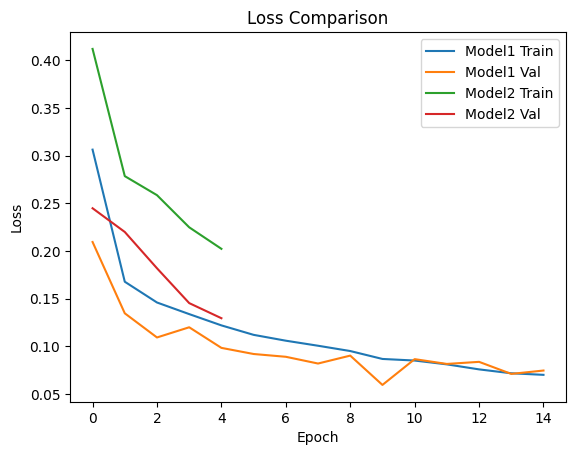

In [14]:
# Plot training loss
plt.plot(history1.history['loss'], label='Model1 Train')
plt.plot(history1.history['val_loss'], label='Model1 Val')

plt.plot(history2.history['loss'], label='Model2 Train')
plt.plot(history2.history['val_loss'], label='Model2 Val')

plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

ROC Curve

1336/1336 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


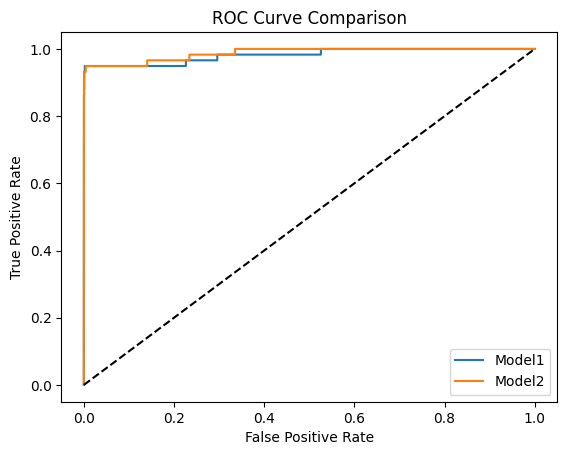

In [15]:
# ROC curve comparison
def plot_roc(model, X_test, y_test, label):
    y_prob = model.predict(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=label)

plt.figure()

plot_roc(model1, X_test, y_test, "Model1")
plot_roc(model2, X_test, y_test, "Model2")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

10. Save Best Model

In [16]:
# Save best model (assume model2 is better)
model2.save("fraud_model.h5")